# 03 — Type Distribution

> **Key question**: How are types distributed across all Pokémon? Which types are common or rare, and what does that mean for team diversity?
> well-built team should avoid stacking the same type twice — this chart helps identify underrepresented types that bring unique coverage.

**Prerequisite**: run `01_data_loading_cleaning.ipynb` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import pickle
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC', 'stellar': '#40B5A5',
}

with open('../data/pokemon_processed.pkl', 'rb') as f:
    df = pickle.load(f)
print(f'Données chargées : {df.shape[0]} Pokémon')

Données chargées : 1025 Pokémon


## 1. Fréquence de chaque type


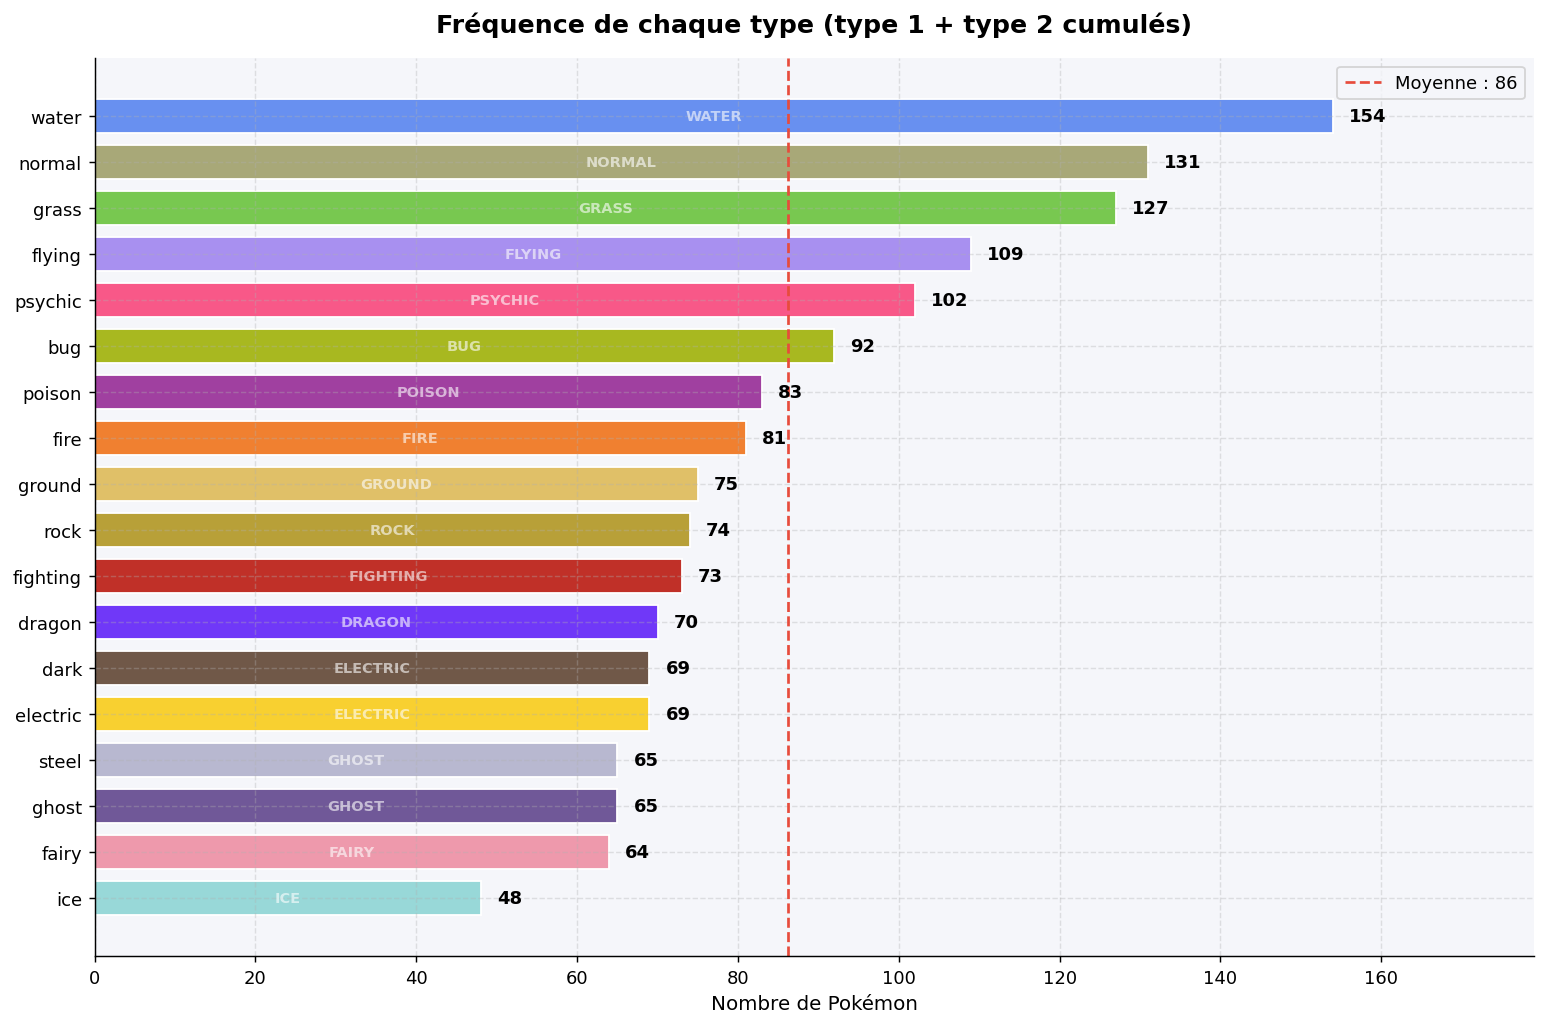

In [2]:
all_types = [t for types in df['types'] for t in types]
type_counts = pd.Series(Counter(all_types)).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [TYPE_COLORS.get(t, '#888') for t in type_counts.index]
bars = ax.barh(type_counts.index, type_counts.values, color=colors,
               edgecolor='white', linewidth=1, height=0.75)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height()/2,
            type_counts.index[list(type_counts.values).index(val)].upper(),
            va='center', ha='center', fontsize=8, color='white',
            fontweight='bold', alpha=0.6)

ax.set_title('Fréquence de chaque type (type 1 + type 2 cumulés)', pad=14)
ax.set_xlabel('Nombre de Pokémon')
ax.set_xlim(0, type_counts.max() + 25)
ax.axvline(type_counts.mean(), color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Moyenne : {type_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Mono-type vs Dual-type (donut)


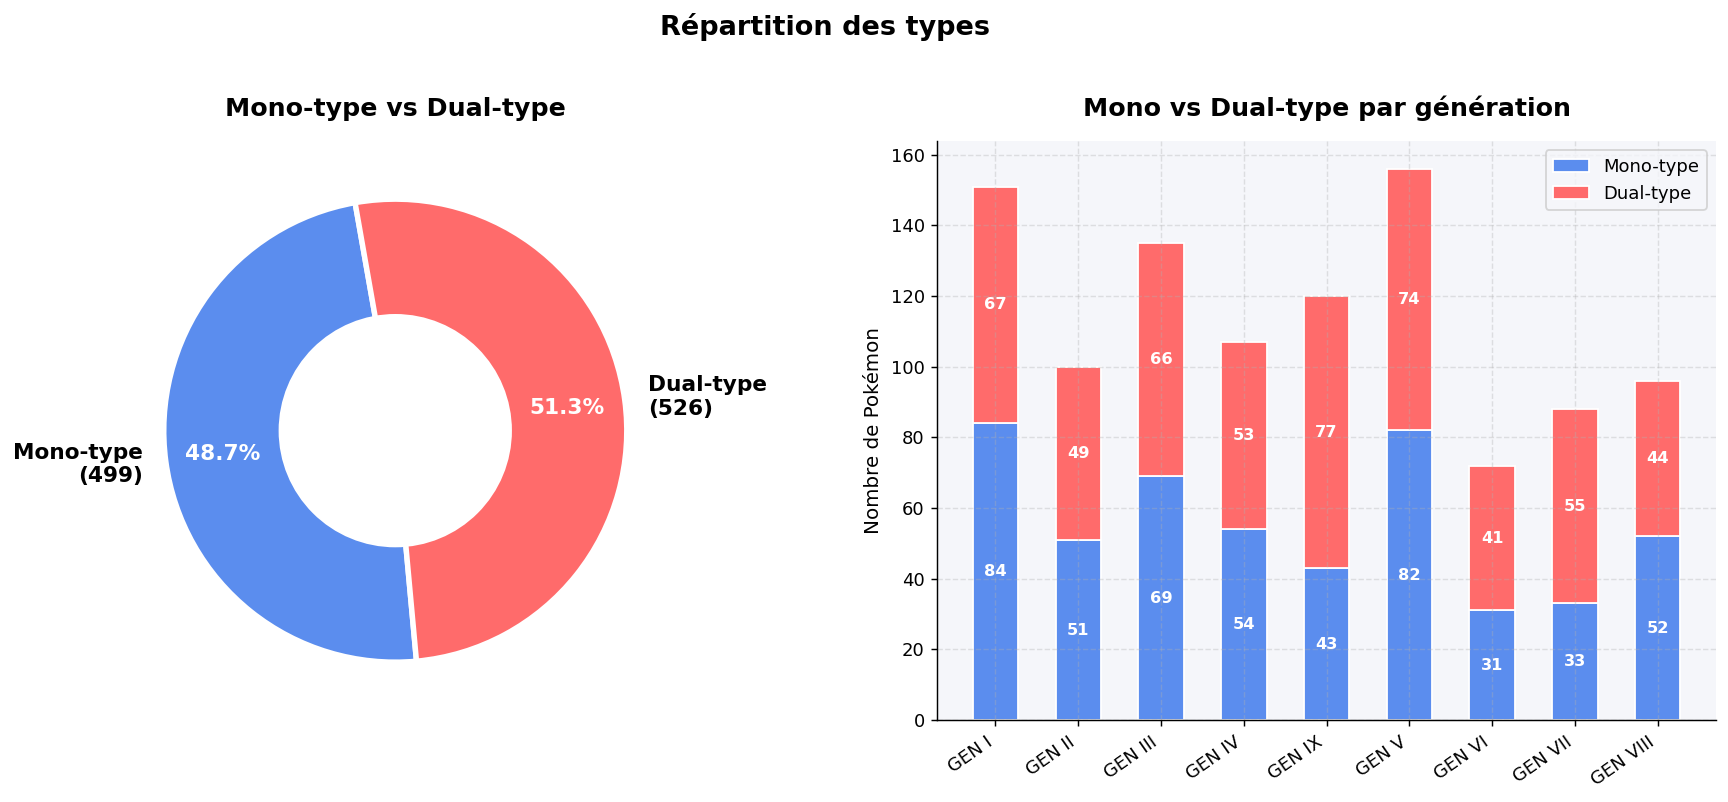

In [3]:
mono = (df['n_types'] == 1).sum()
dual = (df['n_types'] == 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
wedge_props = {'edgecolor': 'white', 'linewidth': 3}
wedges, texts, autotexts = ax.pie(
    [mono, dual],
    labels=[f'Mono-type\n({mono})', f'Dual-type\n({dual})'],
    autopct='%1.1f%%',
    colors=['#5B8DEE', '#FF6B6B'],
    startangle=100,
    wedgeprops=wedge_props,
    pctdistance=0.75,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(12)
    at.set_fontweight('bold')
circle = plt.Circle((0, 0), 0.5, color='white')
ax.add_artist(circle)
ax.set_title('Mono-type vs Dual-type', pad=14)

ax2 = axes[1]
gen_order = sorted(df['generation'].unique())
mono_counts = [df[(df['generation']==g) & (df['n_types']==1)].shape[0] for g in gen_order]
dual_counts = [df[(df['generation']==g) & (df['n_types']==2)].shape[0] for g in gen_order]
gen_labels = [g.replace('generation-', 'Gen ').upper() for g in gen_order]
x = np.arange(len(gen_order))
width = 0.55
b1 = ax2.bar(x, mono_counts, width, label='Mono-type', color='#5B8DEE', edgecolor='white')
b2 = ax2.bar(x, dual_counts, width, bottom=mono_counts, label='Dual-type', color='#FF6B6B', edgecolor='white')
for i, (m, d) in enumerate(zip(mono_counts, dual_counts)):
    ax2.text(i, m / 2, str(m), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax2.text(i, m + d / 2, str(d), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(gen_labels, rotation=35, ha='right')
ax2.set_title('Mono vs Dual-type par génération', pad=14)
ax2.set_ylabel('Nombre de Pokémon')
ax2.legend()

plt.suptitle('Répartition des types', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Heatmap des combinaisons de types


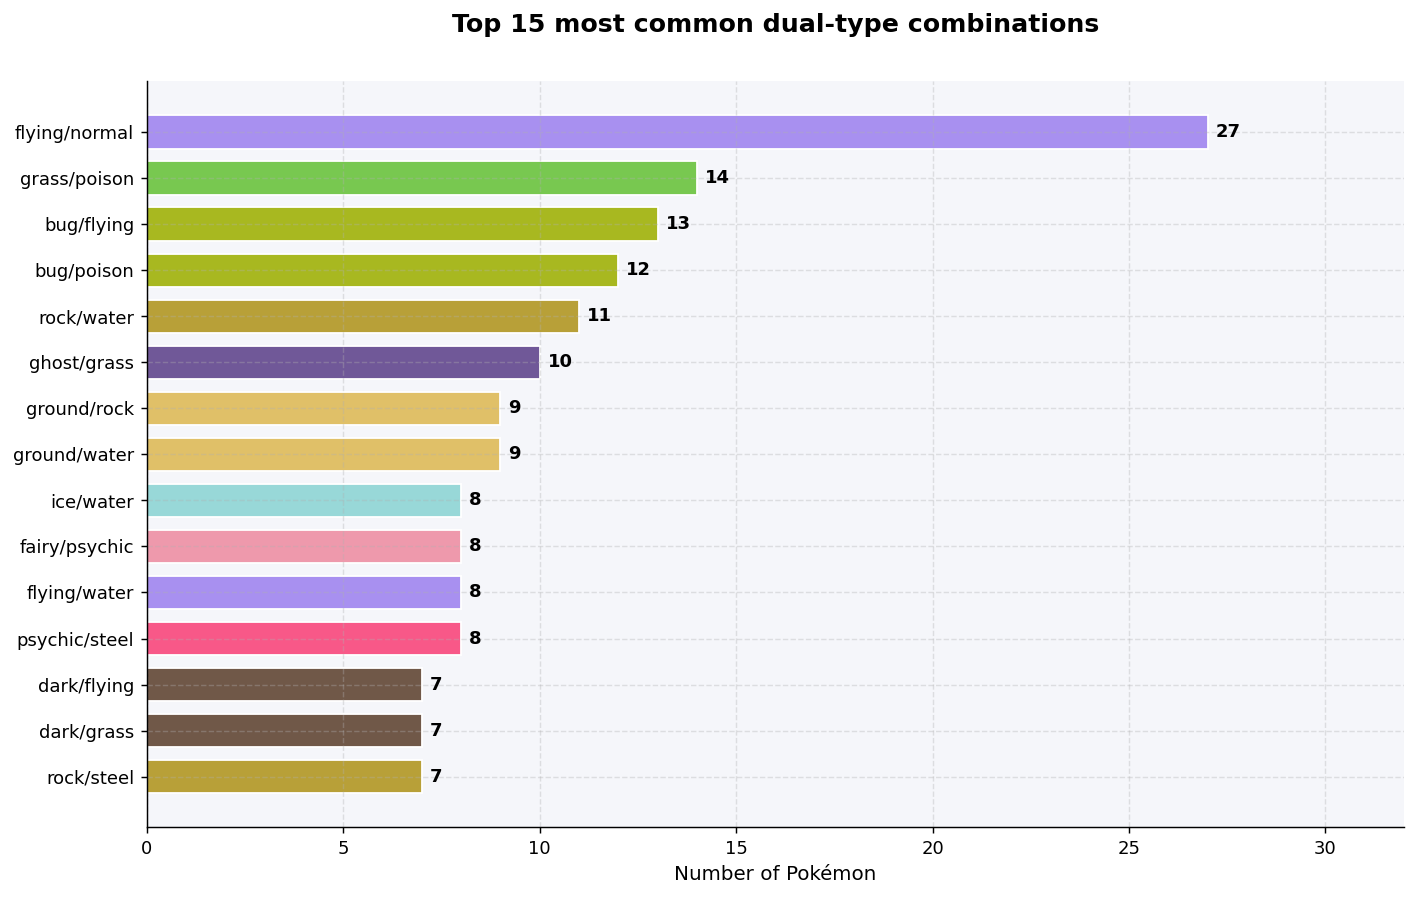

In [5]:
dual_df_only = df[df['n_types'] == 2].copy()
top_combos = []
for _, row in dual_df_only.iterrows():
    t1, t2 = sorted([row['type1'], row['type2']])
    top_combos.append(f'{t1}/{t2}')
combo_counts = pd.Series(top_combos).value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [TYPE_COLORS.get(c.split('/')[0], '#888') for c in combo_counts.index]
bars = ax.barh(combo_counts.index[::-1], combo_counts.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.72)
for bar, val in zip(bars, combo_counts.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title(
    'Top 15 most common dual-type combinations\n',
    pad=12
)
ax.set_xlabel('Number of Pokémon')
ax.set_xlim(0, combo_counts.max() + 5)
plt.tight_layout()
plt.show()
